# Indian Currency Recognition
This project trains a ML model to recognise Indian Currency notes. There are 6 denominations of Indian Currency notes as of now(2026). They are as follows:<br>
1. Rs. 10
2. Rs. 20
3. Rs. 50
4. Rs. 100
5. Rs. 200
6. Rs. 500
<br>Rs. 2000 notes, though not currently produced, is still under circulation. So images with 2000 rupee notes are also considered.

This dataset is divided into 3 directories Train, Test, Validation. The Train and Validation folders contain images for the currencies and background images representative of images with no currency in them. The data is stored as jpeg images. 

**Import required libraries**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

**Loading the dataset**

In [3]:
#Defining the classes and assigning labels
currency_class = {
    'Background' : 0,
    '10' : 1,
    '20' : 2,
    '50' : 3,
    '100' : 4,
    '200' : 5,
    '500' : 6,
    '2000' : 7
}

In [3]:
import os
import cv2
from pathlib import Path
train_paths = os.listdir('./Indian currency dataset v1/training') #Gets the filenames in the folder

train_img_data = []
y_train=[]#Classes of the image
#Extracting the images from the subfolders one by one
for file in train_paths:
    #Finding the class for the image
    for currency,label in currency_class.items():
        if currency in file:
            class_label = label
    folder_path = os.path.join('./Indian currency dataset v1/training/', file)
    imgs = os.listdir(folder_path)
    for each in imgs:
        img_path = os.path.join(folder_path,each)
        img_path = (Path(folder_path) / each).as_posix()
        img = cv2.imread(img_path,cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.resize(img, (256, 256))   # force same size 
        train_img_data.append(img)
        y_train.append(class_label)

train_img = np.stack(train_img_data)

print(train_img.shape)
print(y_train)

(3566, 256, 256, 3)
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
import os
import cv2
val_paths = os.listdir('./Indian currency dataset v1/validation') #Gets the filenames in the folder

val_img_data = []
y_val=[]#Classes of the image
#Extracting the images from the subfolders one by one
for file in val_paths:
    #Finding the class for the image
    for currency,label in currency_class.items():
        if currency in file:
            class_label = label
    folder_path = os.path.join('./Indian currency dataset v1/validation/', file)
    imgs = os.listdir(folder_path)
    for each in imgs:
        img_path = os.path.join(folder_path,each)
        img_path = (Path(folder_path) / each).as_posix()
        img = cv2.imread(img_path,cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.resize(img, (256, 256))   # force same size 
        val_img_data.append(img)
        y_val.append(class_label)

val_img = np.stack(val_img_data)

print(val_img.shape)
print(y_val)

(345, 256, 256, 3)
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [5]:
import os
import cv2
test_paths = os.listdir('./Indian currency dataset v1/test') #Gets the filenames in the folder

test_img_data = []
y_test=[]
#Extracting the images from the subfolders one by one
for file in test_paths:
    for currency,label in currency_class.items():
        if currency in file:
            class_label = label
    img_path = os.path.join('./Indian currency dataset v1/test/', file)
    img = cv2.imread(img_path,cv2.IMREAD_COLOR)
    if img is None:
        continue
    img = cv2.resize(img, (256, 256))   # force same size 
    test_img_data.append(img)
    y_test.append(class_label)

test_img = np.stack(test_img_data)

print(test_img.shape)
print(y_test)

(91, 256, 256, 3)
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 1, 1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 1, 0, 0]


## Training

In [6]:
#Normalising the image pixels to [0,1]
x_train = train_img.astype('float32') / 255
x_test = test_img.astype('float32') / 255
x_val = val_img.astype('float32') / 255
#Converting y_train,y_text and y_val into numpy array
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [41]:
#DEfining the CNN
from tensorflow.keras import datasets, layers, models
from tensorflow.keras import models, layers

model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same',
                  input_shape=(256,256,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # Classification Head
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256, 256, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 256, 256, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,688 (436.28 KB)

 Trainable params: 111,240 (434.53 KB)

 Non-trainable params: 448 (1.75 KB)

In [84]:
from tensorflow.keras.callbacks import EarlyStopping
'''
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)
'''
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, 
                   validation_data=(x_val, y_val)#,
                    #callbacks=[early_stop]
                   )


Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.5345 - loss: 1.3195 - val_accuracy: 0.4058 - val_loss: 1.7522
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 290s 3s/step - accuracy: 0.5578 - loss: 1.2462 - val_accuracy: 0.3739 - val_loss: 1.9924
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.5754 - loss: 1.1693 - val_accuracy: 0.6116 - val_loss: 1.1536
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.6060 - loss: 1.1326 - val_accuracy: 0.6145 - val_loss: 1.2033
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - accuracy: 0.6169 - loss: 1.0990 - val_accuracy: 0.5652 - val_loss: 1.1969
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - accuracy: 0.6242 - loss: 1.0522 - val_accuracy: 0.5362 - val_loss: 1.5455
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 285s 3s/step - accuracy: 0.6408 - loss: 1.0254 - val_accuracy: 0.5739 - val_loss: 1.2048
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 329s 3s/step - accuracy: 0.6506 - loss: 1.0065 - val_accu

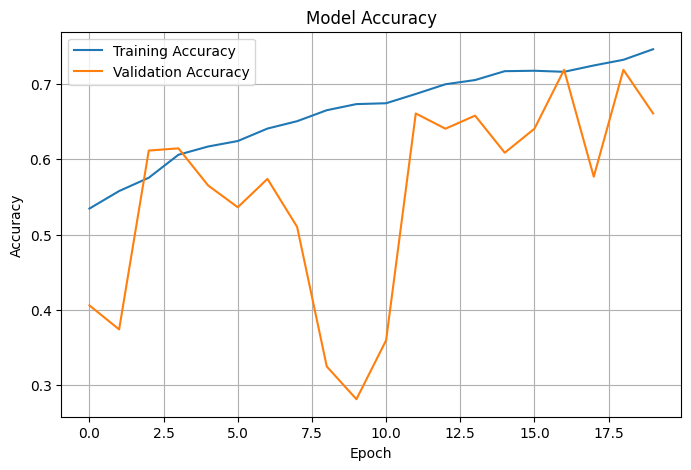

In [86]:
#Plot the accuracy values from training

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### Evaluation

(256, 256, 3)

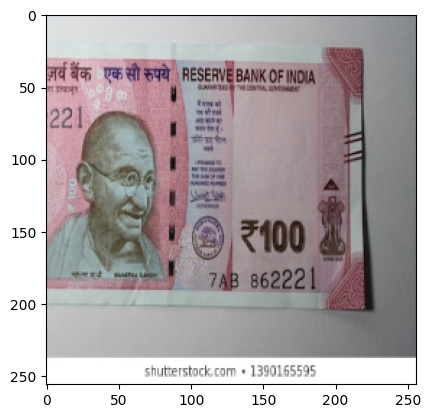

In [92]:
#Testing for one test image
plt.imshow(x_test[0])
x_test[0].shape

In [94]:
img = np.expand_dims(x_test[0], axis=0)
predictions = model.predict(img)
predicted_class = np.argmax(predictions, axis=1)[0]
for currency,label in currency_class.items():
    if label==predicted_class:
        print(currency)
        break     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
100


The prediction is correct

In [99]:
#Evaluation
y_pred = np.argmax(model.predict(x_test), axis=1)
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 392ms/step
              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.60      0.43      0.50         7
           2       0.73      0.92      0.81        12
           3       1.00      0.21      0.35        14
           4       1.00      0.36      0.53        14
           5       0.59      0.87      0.70        15
           6       0.55      1.00      0.71        11
           7       0.89      0.73      0.80        11

    accuracy                           0.66        91
   macro avg       0.73      0.67      0.63        91
weighted avg       0.76      0.66      0.63        91



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step


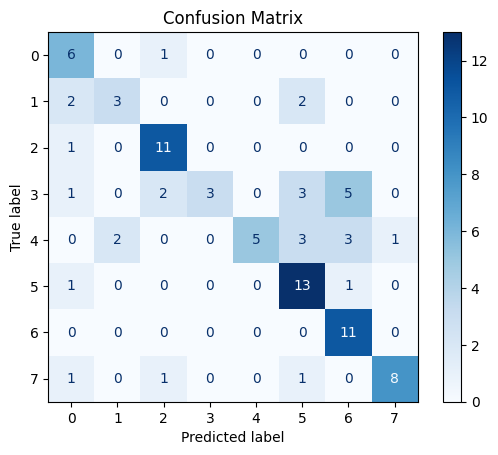

In [103]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# True labels
y_true = y_test

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        0,1,2,3,4,5,6,7
    ]
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Overall accuracy of the model is 66%. The classes 2,5 and 6 are strong classes along with 0 and 7. The number of true predictions are high here. The model perform poorly for classes 1,3 and 4.

**Trying pretrained ResNet50 model and data augmentation**

In [8]:
from tensorflow.keras import datasets, layers, models

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [9]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False#Freeze backbone

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [12]:
inputs = layers.Input(shape=(256, 256, 3))

# Data augmentation
x = data_augmentation(inputs)

#Preprocessing
x = tf.keras.applications.resnet50.preprocess_input(x)

# ResNet backbone
x = base_model(x, training=False)

# Classification head (similar structure to yours)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(8, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_img, y_train, epochs=20, 
                   validation_data=(val_img, y_val)#,No need to do /255 as preprocessing is done by resnet
                    #callbacks=[early_stop]
                   )

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 363s 3s/step - accuracy: 0.2765 - loss: 2.0506 - val_accuracy: 0.5072 - val_loss: 1.5397
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.4790 - loss: 1.4754 - val_accuracy: 0.6377 - val_loss: 1.2131
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.5906 - loss: 1.1841 - val_accuracy: 0.7014 - val_loss: 0.9827
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.6439 - loss: 1.0357 - val_accuracy: 0.6928 - val_loss: 0.8658
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.6913 - loss: 0.9079 - val_accuracy: 0.7507 - val_loss: 0.7570
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.7221 - loss: 0.8248 - val_accuracy: 0.7913 - val_loss: 0.6824
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.7541 - loss: 0.7273 - val_accuracy: 0.8000 - val_loss: 0.6120
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 354s 3s/step - accuracy: 0.7717 - loss: 0.6863 - val_accu

In [14]:
#Evaluation
y_pred = np.argmax(model.predict(test_img), axis=1)
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step
              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       0.55      0.86      0.67         7
           2       0.91      0.83      0.87        12
           3       0.89      0.57      0.70        14
           4       0.74      1.00      0.85        14
           5       1.00      0.80      0.89        15
           6       1.00      0.82      0.90        11
           7       1.00      1.00      1.00        11

    accuracy                           0.85        91
   macro avg       0.86      0.86      0.84        91
weighted avg       0.88      0.85      0.85        91



3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


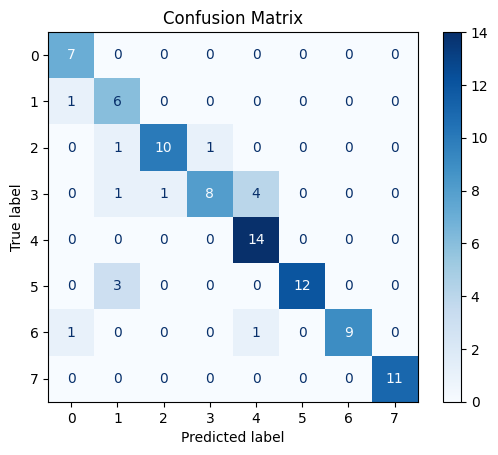

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Predictions
y_pred = np.argmax(model.predict(test_img), axis=1)

# True labels
y_true = y_test

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        0,1,2,3,4,5,6,7
    ]
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

This is definitely a better model, with 85% accuracy and less false predictions

In [17]:
#Saving the model
model.save("currency_classifier.keras")

In [19]:
#Loading the model

model = tf.keras.models.load_model("currency_classifier.keras")
loss, accuracy = model.evaluate(test_img,y_test)
print(f"Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8462 - loss: 0.5164
Accuracy: 0.8462
